In [1]:
import pandas as pd

df_id = pd.read_csv('../data/train_identity.csv')#, nrows=100)

print(df_id.head())

   TransactionID  id_01     id_02  id_03  id_04  id_05  id_06  id_07  id_08  \
0        2987004    0.0   70787.0    NaN    NaN    NaN    NaN    NaN    NaN   
1        2987008   -5.0   98945.0    NaN    NaN    0.0   -5.0    NaN    NaN   
2        2987010   -5.0  191631.0    0.0    0.0    0.0    0.0    NaN    NaN   
3        2987011   -5.0  221832.0    NaN    NaN    0.0   -6.0    NaN    NaN   
4        2987016    0.0    7460.0    0.0    0.0    1.0    0.0    NaN    NaN   

   id_09  ...                id_31  id_32      id_33           id_34  id_35  \
0    NaN  ...  samsung browser 6.2   32.0  2220x1080  match_status:2      T   
1    NaN  ...   mobile safari 11.0   32.0   1334x750  match_status:1      T   
2    0.0  ...          chrome 62.0    NaN        NaN             NaN      F   
3    NaN  ...          chrome 62.0    NaN        NaN             NaN      F   
4    0.0  ...          chrome 62.0   24.0   1280x800  match_status:2      T   

  id_36 id_37  id_38  DeviceType                  

In [2]:
df_trans = pd.read_csv('../data/train_transaction.csv')#, nrows=100)

print(df_trans.head())

   TransactionID  isFraud  TransactionDT  TransactionAmt ProductCD  card1  \
0        2987000        0          86400            68.5         W  13926   
1        2987001        0          86401            29.0         W   2755   
2        2987002        0          86469            59.0         W   4663   
3        2987003        0          86499            50.0         W  18132   
4        2987004        0          86506            50.0         H   4497   

   card2  card3       card4  card5  ... V330  V331  V332  V333  V334 V335  \
0    NaN  150.0    discover  142.0  ...  NaN   NaN   NaN   NaN   NaN  NaN   
1  404.0  150.0  mastercard  102.0  ...  NaN   NaN   NaN   NaN   NaN  NaN   
2  490.0  150.0        visa  166.0  ...  NaN   NaN   NaN   NaN   NaN  NaN   
3  567.0  150.0  mastercard  117.0  ...  NaN   NaN   NaN   NaN   NaN  NaN   
4  514.0  150.0  mastercard  102.0  ...  0.0   0.0   0.0   0.0   0.0  0.0   

  V336  V337  V338  V339  
0  NaN   NaN   NaN   NaN  
1  NaN   NaN   NaN  

### check for duplicate transactionIDs in either dataframe, since it would lead to problems.

In [3]:
print(df_id.duplicated('TransactionID').sum())
print(df_trans.duplicated('TransactionID').sum())

0
0


### combine transactions and identifiers into one dataframe

In [4]:
df = df_trans.merge(df_id, how='left', on='TransactionID', validate='one_to_one')

In [5]:
df.select_dtypes(include=('str','object')).nunique().sort_values()

M2                  2
M3                  2
M1                  2
id_12               2
M8                  2
M7                  2
M6                  2
M5                  2
M9                  2
id_36               2
id_37               2
id_38               2
id_29               2
id_28               2
id_27               2
id_16               2
DeviceType          2
id_35               2
M4                  3
id_23               3
id_15               3
card4               4
id_34               4
card6               4
ProductCD           5
P_emaildomain      59
R_emaildomain      60
id_30              75
id_31             130
id_33             260
DeviceInfo       1786
dtype: int64

### drop all non-numeric fields

In [6]:
'''string_cols = df.select_dtypes(include=['str', 'object', 'category']).columns
print(string_cols)

#df[string_cols] = df[string_cols].astype('category')

df.drop(columns=string_cols, inplace=True)


print(df.columns.tolist())'''

"string_cols = df.select_dtypes(include=['str', 'object', 'category']).columns\nprint(string_cols)\n\n#df[string_cols] = df[string_cols].astype('category')\n\ndf.drop(columns=string_cols, inplace=True)\n\n\nprint(df.columns.tolist())"

In [7]:
list(df.dtypes.items())

[('TransactionID', dtype('int64')),
 ('isFraud', dtype('int64')),
 ('TransactionDT', dtype('int64')),
 ('TransactionAmt', dtype('float64')),
 ('ProductCD', <StringDtype(na_value=nan)>),
 ('card1', dtype('int64')),
 ('card2', dtype('float64')),
 ('card3', dtype('float64')),
 ('card4', <StringDtype(na_value=nan)>),
 ('card5', dtype('float64')),
 ('card6', <StringDtype(na_value=nan)>),
 ('addr1', dtype('float64')),
 ('addr2', dtype('float64')),
 ('dist1', dtype('float64')),
 ('dist2', dtype('float64')),
 ('P_emaildomain', <StringDtype(na_value=nan)>),
 ('R_emaildomain', <StringDtype(na_value=nan)>),
 ('C1', dtype('float64')),
 ('C2', dtype('float64')),
 ('C3', dtype('float64')),
 ('C4', dtype('float64')),
 ('C5', dtype('float64')),
 ('C6', dtype('float64')),
 ('C7', dtype('float64')),
 ('C8', dtype('float64')),
 ('C9', dtype('float64')),
 ('C10', dtype('float64')),
 ('C11', dtype('float64')),
 ('C12', dtype('float64')),
 ('C13', dtype('float64')),
 ('C14', dtype('float64')),
 ('D1', dtype

In [8]:
print(df.drop('isFraud',axis=1).shape)
print(df['isFraud'].shape)

(590540, 433)
(590540,)


### convert low cardinality fields to categories

In [9]:
low_card_cols = [c for c in df.select_dtypes(include=('str','object')).columns 
                 if df[c].nunique() <= 5 and c != 'isFraud']
print(low_card_cols)

high_card_cols = [c for c in df.select_dtypes(include=('str','object')).columns 
                 if df[c].nunique() > 5]
print(high_card_cols)

df[low_card_cols] = df[low_card_cols].astype('category')

['ProductCD', 'card4', 'card6', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'id_12', 'id_15', 'id_16', 'id_23', 'id_27', 'id_28', 'id_29', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38', 'DeviceType']
['P_emaildomain', 'R_emaildomain', 'id_30', 'id_31', 'id_33', 'DeviceInfo']


In [10]:
df['P_emaildomain'].value_counts(dropna=False).head(5)

P_emaildomain
gmail.com        228355
yahoo.com        100934
NaN               94456
hotmail.com       45250
anonymous.com     36998
Name: count, dtype: int64

### to prevent data leakage, time-split the training and test sets, with a buffer in between

In [11]:
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score

from xgboost import XGBClassifier

train_idx = df['TransactionDT'] <= df['TransactionDT'].quantile(0.75)
test_idx = df['TransactionDT'] > df['TransactionDT'].quantile(0.80)

X_train, X_test, y_train, y_test = (
    df.drop('isFraud',axis=1)[train_idx],
    df.drop('isFraud',axis=1)[test_idx],
    df['isFraud'][train_idx],
    df['isFraud'][test_idx]
)
print(y_test[0:5])

#train = df[df['TransactionDT'] <= train_cutoff]
#test = df[df['TransactionDT'] >= test_start]

#print(f"Train fraud rate: {y_train.mean():.4f}")
#print(f"Test fraud rate:  {y_test.mean():.4f}")

'''X_train, X_test, y_train, y_test = train_test_split(
    df.drop('isFraud',axis=1),
    df['isFraud'],
    test_size=0.2,
    stratify=df['isFraud'],
    random_state=42
)'''

472432    1
472433    0
472434    0
472435    0
472436    0
Name: isFraud, dtype: int64


"X_train, X_test, y_train, y_test = train_test_split(\n    df.drop('isFraud',axis=1),\n    df['isFraud'],\n    test_size=0.2,\n    stratify=df['isFraud'],\n    random_state=42\n)"

/tmp/ipykernel_16197/2981363153.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X['day_of_week'] = (X['TransactionDT'] // SECONDS_PER_DAY) % 7
/tmp/ipykernel_16197/2981363153.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X['time_of_week'] = (X['TransactionDT'] % (SECONDS_PER_DAY * 7)) / 3600
/tmp/ipykernel_16197/2981363153.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.

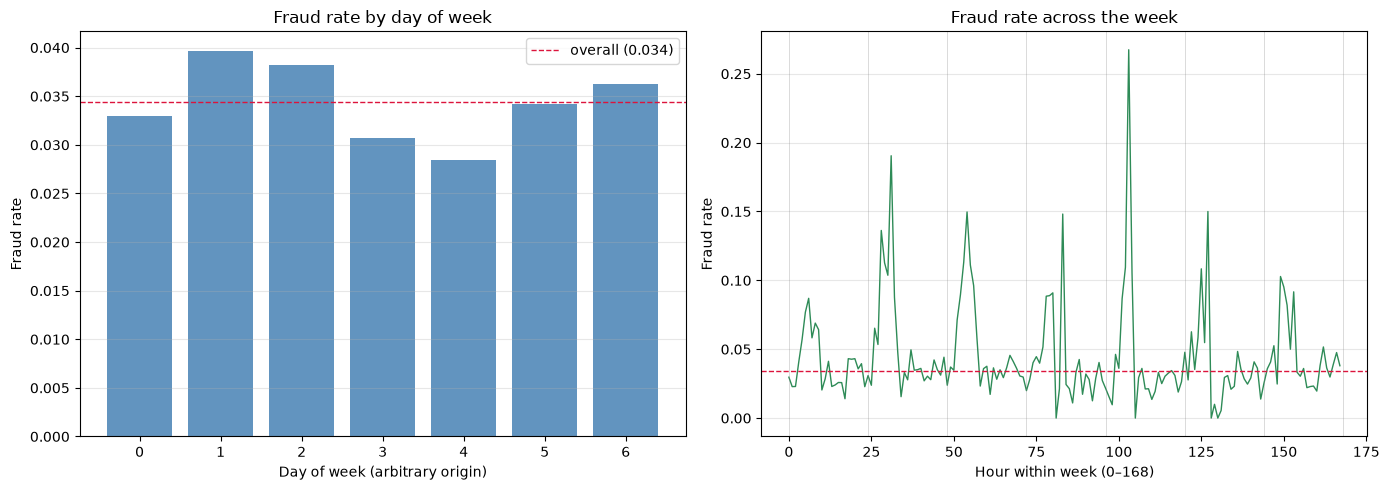

In [12]:
import matplotlib.pyplot as plt
import numpy as np

SECONDS_PER_DAY = 60*60*24

if 'TransactionDT' in X_train:
    for X in (X_train, X_test):
        X['day_of_week'] = (X['TransactionDT'] // SECONDS_PER_DAY) % 7
        X['time_of_week'] = (X['TransactionDT'] % (SECONDS_PER_DAY * 7)) / 3600

    X_train = X_train.drop(columns=['TransactionDT'])
    X_test  = X_test.drop(columns=['TransactionDT'])

df_plot = X_test.copy()
df_plot['isFraud'] = y_test.values

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- fraud rate by day of week ---
by_day = df_plot.groupby('day_of_week')['isFraud'].agg(['mean', 'size'])

axes[0].bar(by_day.index, by_day['mean'], color='steelblue', alpha=0.85)
axes[0].axhline(df_plot['isFraud'].mean(), ls='--', color='crimson', lw=1,
                label=f"overall ({df_plot['isFraud'].mean():.3f})")
axes[0].set_xlabel('Day of week (arbitrary origin)')
axes[0].set_ylabel('Fraud rate')
axes[0].set_title('Fraud rate by day of week')
axes[0].legend()
axes[0].grid(alpha=0.3, axis='y')

# --- fraud rate by hour within the week ---
bins = np.arange(0, 169, 1)                     # 1-hour bins across 168h
df_plot['tow_bin'] = pd.cut(df_plot['time_of_week'], bins, labels=bins[:-1])
by_tow = df_plot.groupby('tow_bin', observed=True)['isFraud'].agg(['mean', 'size'])

axes[1].plot(by_tow.index.astype(float), by_tow['mean'], lw=1, color='seagreen')
axes[1].axhline(df_plot['isFraud'].mean(), ls='--', color='crimson', lw=1)
for d in range(0, 169, 24):                     # day boundaries
    axes[1].axvline(d, color='grey', lw=0.5, alpha=0.4)
axes[1].set_xlabel('Hour within week (0–168)')
axes[1].set_ylabel('Fraud rate')
axes[1].set_title('Fraud rate across the week')
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### looking at the second plot, clearly time of day would be a useful feature

/tmp/ipykernel_16197/3142390383.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X['time_of_day'] = (X['time_of_week'] % 24) # the units of time_of_week are hours


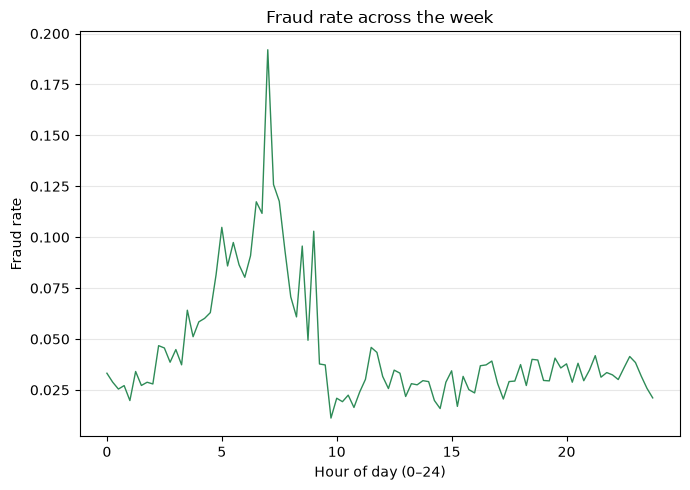

In [13]:
for X in (X_train, X_test):
    X['time_of_day'] = (X['time_of_week'] % 24) # the units of time_of_week are hours 

df_plot = X_test.copy()
df_plot['isFraud'] = y_test.values

fig, axes = plt.subplots(figsize=(7, 5))

# --- fraud rate by hour within the week ---
bins = np.arange(0, 24*4+1, 0.25)                     # 15-min bins
df_plot['tod_bin'] = pd.cut(df_plot['time_of_day'], bins, labels=bins[:-1])
by_tod = df_plot.groupby('tod_bin', observed=True)['isFraud'].agg(['mean', 'size'])

axes.plot(by_tod.index.astype(float), by_tod['mean'], lw=1, color='seagreen')
axes.set_xlabel('Hour of day (0–24)')
axes.set_ylabel('Fraud rate')
axes.set_title('Fraud rate across the week')
axes.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### convert high cardinality string fields to their respective counts

In [14]:
for col in high_card_cols:
    freq = X_train[col].value_counts(normalize=True)
    X_train[col + '_freq'] = X_train[col].map(freq)
    X_test[col + '_freq'] = X_test[col].map(freq).fillna(0)

X_train = X_train.drop(columns=high_card_cols)
X_test = X_test.drop(columns=high_card_cols)

/tmp/ipykernel_16197/226209226.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_train[col + '_freq'] = X_train[col].map(freq)
/tmp/ipykernel_16197/226209226.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_test[col + '_freq'] = X_test[col].map(freq).fillna(0)
/tmp/ipykernel_16197/226209226.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a d

In [15]:
df[high_card_cols[0]].value_counts(normalize=True)

P_emaildomain
gmail.com           0.460315
yahoo.com           0.203462
hotmail.com         0.091214
anonymous.com       0.074580
aol.com             0.057025
comcast.net         0.015901
icloud.com          0.012633
outlook.com         0.010272
msn.com             0.008249
att.net             0.008130
live.com            0.006130
sbcglobal.net       0.005987
verizon.net         0.005453
ymail.com           0.004830
bellsouth.net       0.003848
yahoo.com.mx        0.003110
me.com              0.003068
cox.net             0.002808
optonline.net       0.002038
charter.net         0.001645
live.com.mx         0.001510
rocketmail.com      0.001338
mail.com            0.001127
earthlink.net       0.001036
gmail               0.001000
outlook.es          0.000883
mac.com             0.000879
juno.com            0.000649
aim.com             0.000635
hotmail.es          0.000615
roadrunner.com      0.000615
windstream.net      0.000615
hotmail.fr          0.000595
frontier.com        0.000564


In [16]:
list(X_train.dtypes.items())

[('TransactionID', dtype('int64')),
 ('TransactionAmt', dtype('float64')),
 ('ProductCD',
  CategoricalDtype(categories=['C', 'H', 'R', 'S', 'W'], ordered=False, categories_dtype=str)),
 ('card1', dtype('int64')),
 ('card2', dtype('float64')),
 ('card3', dtype('float64')),
 ('card4',
  CategoricalDtype(categories=['american express', 'discover', 'mastercard', 'visa'], ordered=False, categories_dtype=str)),
 ('card5', dtype('float64')),
 ('card6',
  CategoricalDtype(categories=['charge card', 'credit', 'debit', 'debit or credit'], ordered=False, categories_dtype=str)),
 ('addr1', dtype('float64')),
 ('addr2', dtype('float64')),
 ('dist1', dtype('float64')),
 ('dist2', dtype('float64')),
 ('C1', dtype('float64')),
 ('C2', dtype('float64')),
 ('C3', dtype('float64')),
 ('C4', dtype('float64')),
 ('C5', dtype('float64')),
 ('C6', dtype('float64')),
 ('C7', dtype('float64')),
 ('C8', dtype('float64')),
 ('C9', dtype('float64')),
 ('C10', dtype('float64')),
 ('C11', dtype('float64')),
 ('C12

In [17]:
# compute imbalance ratio
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(scale_pos_weight)

print(f"1/Train fraud rate: {1/y_train.mean():.4f}")
print(f"1/Test fraud rate:  {1/y_test.mean():.4f}")

27.458844695752745
1/Train fraud rate: 28.4588
1/Test fraud rate:  29.0620


### scale features

In [18]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

numeric_cols = X_train.select_dtypes(include=['number']).columns.tolist()

ct = ColumnTransformer(
    [('num', StandardScaler(), numeric_cols)],
    remainder='passthrough'
)
ct.set_output(transform='pandas')


pipe = Pipeline([
    ('prep', ct),
    ('model', XGBClassifier(
        enable_categorical=True,
        n_estimators=200,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        eval_metric="logloss",
        random_state=42
    ))
])


In [19]:
%%time
pipe.fit(X_train, y_train)

CPU times: user 6min 32s, sys: 8.84 s, total: 6min 41s
Wall time: 1min 14s


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse m

In [20]:
pipe.predict_proba(X_test)[:, 1]

array([0.29537514, 0.09666029, 0.8290352 , ..., 0.11033443, 0.39981097,
       0.21401589], shape=(118108,), dtype=float32)

In [21]:
'''model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42,
    enable_categorical=True
)'''

'model = XGBClassifier(\n    n_estimators=200,\n    max_depth=6,\n    learning_rate=0.05,\n    subsample=0.8,\n    colsample_bytree=0.8,\n    scale_pos_weight=scale_pos_weight,\n    eval_metric="logloss",\n    random_state=42,\n    enable_categorical=True\n)'

In [22]:
# took 83 seconds
#model.fit(X_train, y_train)

In [23]:
# predictions
preds = pipe.predict(X_test)
probs = pipe.predict_proba(X_test)[:, 1]

# evaluation
print(classification_report(y_test, preds))

print("ROC-AUC:", roc_auc_score(y_test, probs))

              precision    recall  f1-score   support

           0       0.99      0.91      0.95    114044
           1       0.22      0.68      0.33      4064

    accuracy                           0.91    118108
   macro avg       0.60      0.80      0.64    118108
weighted avg       0.96      0.91      0.93    118108

ROC-AUC: 0.8966241986705918


              precision    recall  f1-score   support

           0       0.99      0.91      0.95    113975
           1       0.24      0.80      0.37      4133

    accuracy                           0.90    118108
   macro avg       0.61      0.85      0.66    118108
weighted avg       0.97      0.90      0.93    118108

ROC-AUC: 0.9302605349535278

In [24]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, thresholds = precision_recall_curve(y_test, probs)
print("PR-AUC:", average_precision_score(y_test, probs))

PR-AUC: 0.48505836760025783


In [25]:
import numpy as np
from sklearn.metrics import precision_score, recall_score

for t in np.arange(0.1, 0.95, 0.05):
    preds_t = (probs >= t).astype(int)
    p = precision_score(y_test, preds_t)
    r = recall_score(y_test, preds_t)
    n_flagged = preds_t.sum()
    print(f"{t:.2f}  precision={p:.3f}  recall={r:.3f}  flagged={n_flagged}")

0.10  precision=0.049  recall=0.978  flagged=81156
0.15  precision=0.064  recall=0.948  flagged=59985
0.20  precision=0.085  recall=0.916  flagged=43965
0.25  precision=0.105  recall=0.879  flagged=34093
0.30  precision=0.124  recall=0.842  flagged=27607
0.35  precision=0.144  recall=0.806  flagged=22758
0.40  precision=0.165  recall=0.764  flagged=18822
0.45  precision=0.191  recall=0.729  flagged=15509
0.50  precision=0.218  recall=0.683  flagged=12698
0.55  precision=0.249  recall=0.638  flagged=10436
0.60  precision=0.284  recall=0.594  flagged=8501
0.65  precision=0.328  recall=0.547  flagged=6779
0.70  precision=0.386  recall=0.507  flagged=5335
0.75  precision=0.451  recall=0.455  flagged=4094
0.80  precision=0.537  recall=0.416  flagged=3148
0.85  precision=0.651  recall=0.375  flagged=2339
0.90  precision=0.770  recall=0.329  flagged=1740


In [26]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, probs)
#print(precision.tolist())
idx = np.argmax(precision >= 0.50)   # first threshold reaching 50% precision
print(f"threshold={thresholds[idx]:.3f}, recall={recall[idx]:.3f}")

idx = np.argmax(recall <= 0.50)   # first threshold reaching 50% precision
print(f"threshold={thresholds[idx]:.3f}, precision={precision[idx]:.3f}")

threshold=0.780, recall=0.433
threshold=0.705, precision=0.391


In [27]:
# convert transactiondt into better value
# extract lowcard features

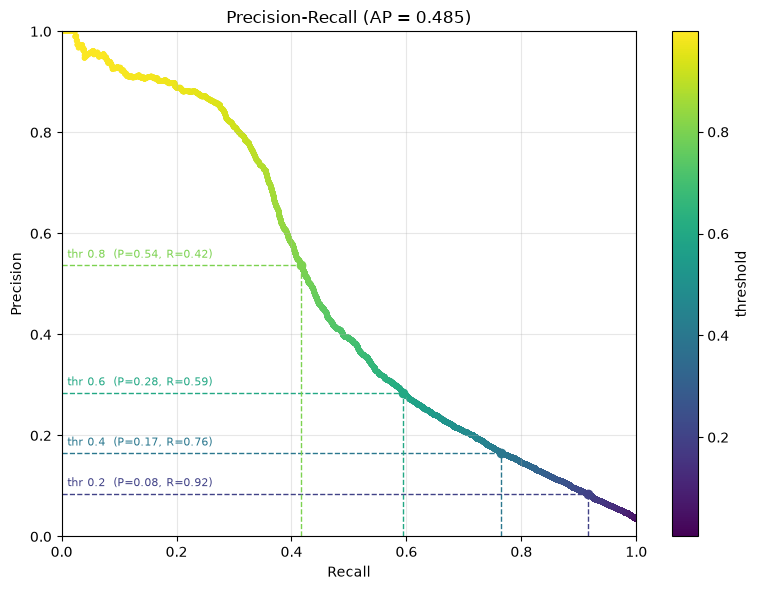

In [28]:
import numpy as np
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, thresholds = precision_recall_curve(y_test, probs)
p, r = precision[:-1], recall[:-1]   # align with thresholds

fig, ax = plt.subplots(figsize=(8, 6))

sc = ax.scatter(r, p, c=thresholds, cmap='viridis', s=8)
plt.colorbar(sc, ax=ax, label='threshold')


targets = [0.2, 0.4, 0.6, 0.8]

for t in targets:
    i = np.searchsorted(thresholds, t)          # thresholds are ascending
    i = min(i, len(thresholds) - 1)
    r_t, p_t = r[i], p[i]
    
    color = sc.cmap(sc.norm(thresholds[i]))

    ax.hlines(p_t, 0, r_t, color=color, ls='--', lw=1)   # y-axis → curve
    ax.vlines(r_t, 0, p_t, color=color, ls='--', lw=1)   # x-axis → curve
    ax.plot(r_t, p_t, 'o', color=color, ms=6)
    ax.text(0.01, p_t + 0.015, f'thr {t}  (P={p_t:.2f}, R={r_t:.2f})',
            color=color, fontsize=8)


ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_title(f'Precision-Recall (AP = {average_precision_score(y_test, probs):.3f})')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

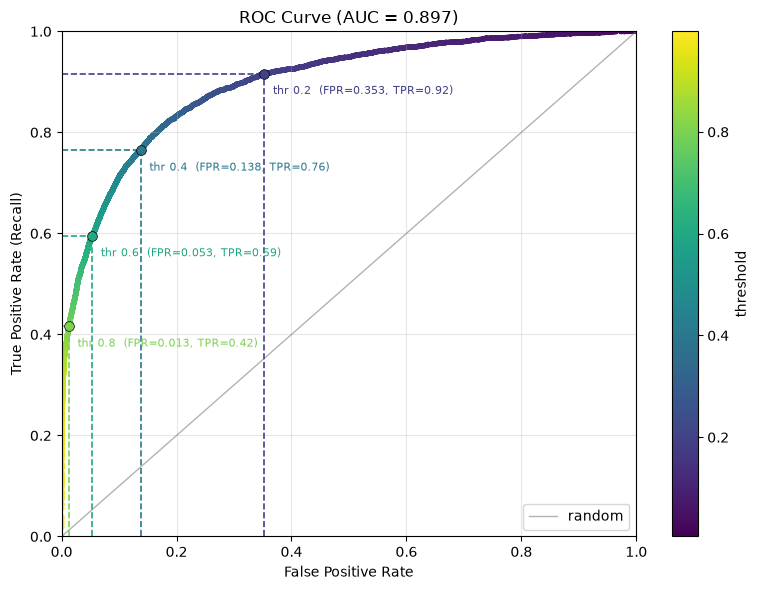

In [29]:
import numpy as np
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, probs)

# roc_curve prepends an infinite threshold for the (0,0) point — drop it
fpr, tpr, thresholds = fpr[1:], tpr[1:], thresholds[1:]

fig, ax = plt.subplots(figsize=(8, 6))

sc = ax.scatter(fpr, tpr, c=thresholds, cmap='viridis', s=8)
plt.colorbar(sc, ax=ax, label='threshold')

ax.plot([0, 1], [0, 1], ls='-', lw=1, color='grey', alpha=0.6, label='random')

targets = [0.2, 0.4, 0.6, 0.8]

for t in targets:
    i = np.argmin(np.abs(thresholds - t))       # thresholds are descending here
    f_t, tp_t = fpr[i], tpr[i]

    color = sc.cmap(sc.norm(thresholds[i]))

    ax.hlines(tp_t, 0, f_t, color=color, ls='--', lw=1.2)
    ax.vlines(f_t, 0, tp_t, color=color, ls='--', lw=1.2)
    ax.plot(f_t, tp_t, 'o', color=color, ms=7, mec='black', mew=0.5)
    ax.text(f_t + 0.015, tp_t - 0.04, f'thr {t}  (FPR={f_t:.3f}, TPR={tp_t:.2f})',
            color=color, fontsize=8)

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate (Recall)')
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_title(f'ROC Curve (AUC = {roc_auc_score(y_test, probs):.3f})')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## make some aggregate features

In [30]:
def decimal_places(s):
    return (s.astype(str)
             .str.split('.').str[1]
             .fillna('')
             .str.rstrip('0')
             .str.len())

X_train['amt_decimals'] = decimal_places(X_train['TransactionAmt'])
X_test['amt_decimals']  = decimal_places(X_test['TransactionAmt'])

X_train['amt_decimal'] = ((X_train['TransactionAmt'] % 1) * 1000).round().astype(int)
X_test['amt_decimal']  = ((X_test['TransactionAmt'] % 1) * 1000).round().astype(int)

/tmp/ipykernel_16197/3577793406.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_train['amt_decimals'] = decimal_places(X_train['TransactionAmt'])
/tmp/ipykernel_16197/3577793406.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_test['amt_decimals']  = decimal_places(X_test['TransactionAmt'])
/tmp/ipykernel_16197/3577793406.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd

In [31]:
X_train['n_missing'] = X_train.isna().sum(axis=1)
X_test['n_missing']  = X_test.isna().sum(axis=1)

/tmp/ipykernel_16197/3870104671.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_train['n_missing'] = X_train.isna().sum(axis=1)
/tmp/ipykernel_16197/3870104671.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_test['n_missing']  = X_test.isna().sum(axis=1)


In [32]:
freq = X_train['card1'].value_counts(normalize=True)

X_train['card1_freq'] = X_train['card1'].map(freq)
X_test['card1_freq']  = X_test['card1'].map(freq).fillna(0)

X_train = X_train.drop(columns=['card1'])
X_test  = X_test.drop(columns=['card1'])

/tmp/ipykernel_16197/3233972111.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_train['card1_freq'] = X_train['card1'].map(freq)
/tmp/ipykernel_16197/3233972111.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_test['card1_freq']  = X_test['card1'].map(freq).fillna(0)


In [33]:
df['P_emaildomain']

0                 NaN
1           gmail.com
2         outlook.com
3           yahoo.com
4           gmail.com
             ...     
590535            NaN
590536      gmail.com
590537      gmail.com
590538        aol.com
590539      gmail.com
Name: P_emaildomain, Length: 590540, dtype: str

In [34]:
src = df.set_index('TransactionID')[['P_emaildomain', 'DeviceInfo']]

def add_string_features(X):
    s = src.reindex(X['TransactionID'])
    X['email_provider'] = s['P_emaildomain'].str.split('.').str[0].values
    X['email_tld']      = s['P_emaildomain'].str.split('.').str[-1].values
    X['device_brand']   = s['DeviceInfo'].str.split(r'[ /]').str[0].str.upper().values
    return X

X_train = add_string_features(X_train)
X_test  = add_string_features(X_test)

for col in ['email_provider', 'email_tld', 'device_brand']:
    cats = X_train[col].astype('category').cat.categories
    X_train[col] = pd.Categorical(X_train[col], categories=cats)
    X_test[col]  = pd.Categorical(X_test[col],  categories=cats)

/tmp/ipykernel_16197/828922379.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X['email_provider'] = s['P_emaildomain'].str.split('.').str[0].values
/tmp/ipykernel_16197/828922379.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X['email_tld']      = s['P_emaildomain'].str.split('.').str[-1].values
/tmp/ipykernel_16197/828922379.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using 

In [35]:
numeric_cols = X_train.select_dtypes(include=['number']).columns.tolist()

ct = ColumnTransformer(
    [('num', StandardScaler(), numeric_cols)],
    remainder='passthrough'
)
ct.set_output(transform='pandas')


pipe2 = Pipeline([
    ('prep', ct),
    ('model', XGBClassifier(
        enable_categorical=True,
        n_estimators=200,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        eval_metric="logloss",
        random_state=42
    ))
])
pipe2.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse m

In [36]:
# predictions
preds = pipe2.predict(X_test)
probs = pipe2.predict_proba(X_test)[:, 1]

# evaluation
print(classification_report(y_test, preds))

print("ROC-AUC:", roc_auc_score(y_test, probs))

              precision    recall  f1-score   support

           0       0.99      0.92      0.95    114044
           1       0.22      0.68      0.34      4064

    accuracy                           0.91    118108
   macro avg       0.61      0.80      0.64    118108
weighted avg       0.96      0.91      0.93    118108

ROC-AUC: 0.8912201477631095


In [37]:
precision, recall, thresholds = precision_recall_curve(y_test, probs)
print("PR-AUC:", average_precision_score(y_test, probs))

PR-AUC: 0.47601069181999517


In [38]:
for t in np.arange(0.1, 0.95, 0.05):
    preds_t = (probs >= t).astype(int)
    p = precision_score(y_test, preds_t)
    r = recall_score(y_test, preds_t)
    n_flagged = preds_t.sum()
    print(f"{t:.2f}  precision={p:.3f}  recall={r:.3f}  flagged={n_flagged}")

0.10  precision=0.050  recall=0.971  flagged=79565
0.15  precision=0.065  recall=0.941  flagged=59163
0.20  precision=0.084  recall=0.902  flagged=43682
0.25  precision=0.103  recall=0.863  flagged=33981
0.30  precision=0.123  recall=0.822  flagged=27145
0.35  precision=0.146  recall=0.786  flagged=21930
0.40  precision=0.168  recall=0.752  flagged=18174
0.45  precision=0.195  recall=0.716  flagged=14948
0.50  precision=0.224  recall=0.680  flagged=12326
0.55  precision=0.258  recall=0.642  flagged=10125
0.60  precision=0.296  recall=0.594  flagged=8152
0.65  precision=0.341  recall=0.547  flagged=6513
0.70  precision=0.402  recall=0.502  flagged=5076
0.75  precision=0.467  recall=0.451  flagged=3919
0.80  precision=0.548  recall=0.397  flagged=2942
0.85  precision=0.664  recall=0.348  flagged=2128
0.90  precision=0.779  recall=0.303  flagged=1580


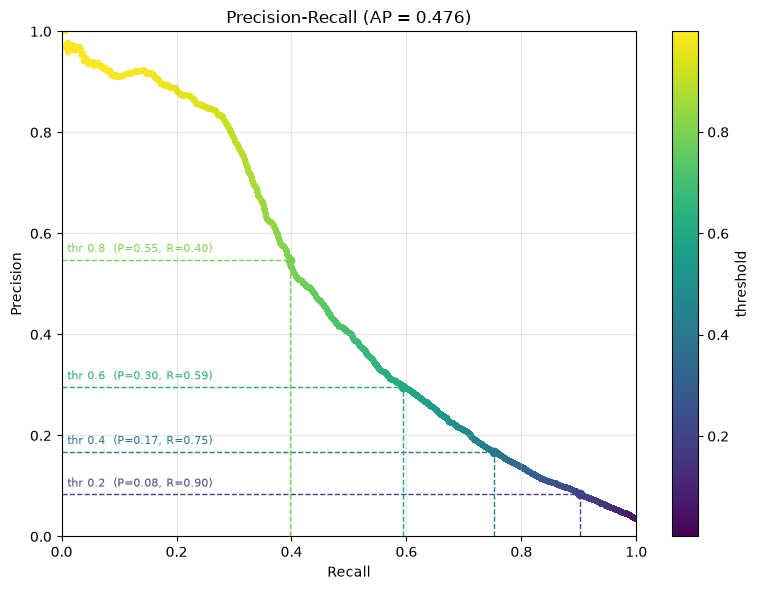

In [39]:
precision, recall, thresholds = precision_recall_curve(y_test, probs)
p, r = precision[:-1], recall[:-1]   # align with thresholds

fig, ax = plt.subplots(figsize=(8, 6))

sc = ax.scatter(r, p, c=thresholds, cmap='viridis', s=8)
plt.colorbar(sc, ax=ax, label='threshold')


targets = [0.2, 0.4, 0.6, 0.8]

for t in targets:
    i = np.searchsorted(thresholds, t)          # thresholds are ascending
    i = min(i, len(thresholds) - 1)
    r_t, p_t = r[i], p[i]
    
    color = sc.cmap(sc.norm(thresholds[i]))

    ax.hlines(p_t, 0, r_t, color=color, ls='--', lw=1)   # y-axis → curve
    ax.vlines(r_t, 0, p_t, color=color, ls='--', lw=1)   # x-axis → curve
    ax.plot(r_t, p_t, 'o', color=color, ms=6)
    ax.text(0.01, p_t + 0.015, f'thr {t}  (P={p_t:.2f}, R={r_t:.2f})',
            color=color, fontsize=8)


ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_title(f'Precision-Recall (AP = {average_precision_score(y_test, probs):.3f})')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

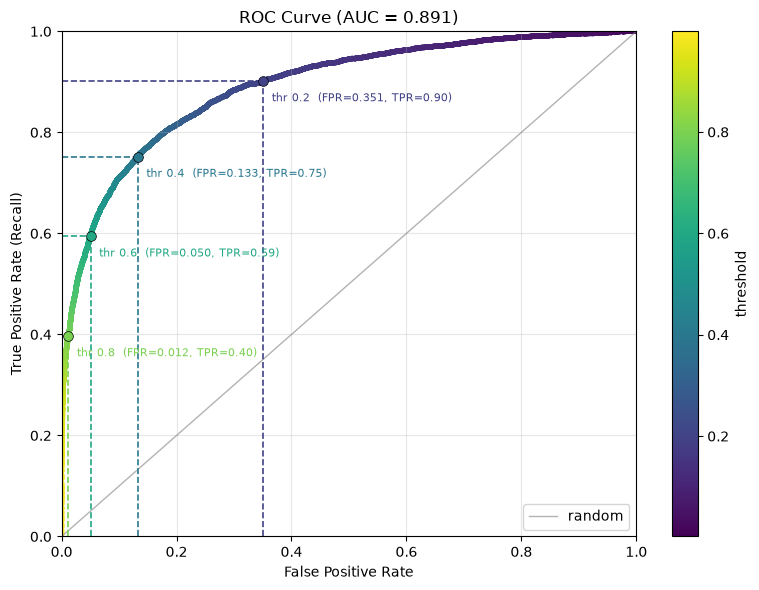

In [40]:
fpr, tpr, thresholds = roc_curve(y_test, probs)

# roc_curve prepends an infinite threshold for the (0,0) point — drop it
fpr, tpr, thresholds = fpr[1:], tpr[1:], thresholds[1:]

fig, ax = plt.subplots(figsize=(8, 6))

sc = ax.scatter(fpr, tpr, c=thresholds, cmap='viridis', s=8)
plt.colorbar(sc, ax=ax, label='threshold')

ax.plot([0, 1], [0, 1], ls='-', lw=1, color='grey', alpha=0.6, label='random')

targets = [0.2, 0.4, 0.6, 0.8]

for t in targets:
    i = np.argmin(np.abs(thresholds - t))       # thresholds are descending here
    f_t, tp_t = fpr[i], tpr[i]

    color = sc.cmap(sc.norm(thresholds[i]))

    ax.hlines(tp_t, 0, f_t, color=color, ls='--', lw=1.2)
    ax.vlines(f_t, 0, tp_t, color=color, ls='--', lw=1.2)
    ax.plot(f_t, tp_t, 'o', color=color, ms=7, mec='black', mew=0.5)
    ax.text(f_t + 0.015, tp_t - 0.04, f'thr {t}  (FPR={f_t:.3f}, TPR={tp_t:.2f})',
            color=color, fontsize=8)

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate (Recall)')
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_title(f'ROC Curve (AUC = {roc_auc_score(y_test, probs):.3f})')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### compute running average of each cards' transaction amounts and time since last transaction

In [41]:
d = df.sort_values('TransactionDT')[['TransactionID', 'card1', 'TransactionAmt']].copy()

g = d.groupby('card1')['TransactionAmt']
print(g)

In [42]:
for i, (name, grp) in enumerate(g):
    if i >= 5:
        break
    print(f"--- card1 = {name} ---")
    print(grp.head(10))

--- card1 = 1000 ---
243924    23.443
Name: TransactionAmt, dtype: float64
--- card1 = 1001 ---
36634     183.0
164336     29.0
223739     27.0
Name: TransactionAmt, dtype: float64
--- card1 = 1004 ---
33767     150.0
41973      30.0
399444     50.0
517371    226.0
517379    226.0
Name: TransactionAmt, dtype: float64
--- card1 = 1005 ---
51871    50.0
Name: TransactionAmt, dtype: float64
--- card1 = 1006 ---
108681    150.0
247681    150.0
449647    100.0
Name: TransactionAmt, dtype: float64


In [43]:
%%time
s = df.loc[df['card1'] == 1004, 'TransactionAmt']

pieces = pd.DataFrame({
    'original': s,
    'shifted': s.shift(1),
    'prior_mean': s.shift(1).expanding().mean(),
})
pieces['ratio'] = pieces['original'] / pieces['prior_mean']

print(pieces.head(20))

        original  shifted  prior_mean     ratio
33767      150.0      NaN         NaN       NaN
41973       30.0    150.0  150.000000  0.200000
399444      50.0     30.0   90.000000  0.555556
517371     226.0     50.0   76.666667  2.947826
517379     226.0    226.0  114.000000  1.982456
CPU times: user 6.6 ms, sys: 20 μs, total: 6.62 ms
Wall time: 5.68 ms


In [44]:
%%time
d = df.sort_values('TransactionDT')[['TransactionID', 'card1', 'TransactionAmt']].copy()

g = d.groupby('card1')['TransactionAmt']
d['card1_amt_mean_prior'] = g.transform(lambda s: s.shift(1).expanding().mean())
d['amt_over_card_mean'] = d['TransactionAmt'] / d['card1_amt_mean_prior']

m = d.set_index('TransactionID')['amt_over_card_mean']
X_train['amt_over_card_mean'] = m.reindex(X_train['TransactionID']).values
X_test['amt_over_card_mean']  = m.reindex(X_test['TransactionID']).values

CPU times: user 2.74 s, sys: 22.8 ms, total: 2.77 s
Wall time: 2.79 s


<timed exec>:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
<timed exec>:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`


In [45]:
%%time
d2 = df.sort_values('TransactionDT')[['TransactionID', 'card1', 'TransactionDT']].copy()

d2['secs_since_card_prev'] = d2['TransactionDT'] - d2.groupby('card1')['TransactionDT'].shift(1)

m2 = d2.set_index('TransactionID')['secs_since_card_prev']
X_train['secs_since_card_prev'] = m2.reindex(X_train['TransactionID']).values
X_test['secs_since_card_prev']  = m2.reindex(X_test['TransactionID']).values

CPU times: user 46.1 ms, sys: 1.95 ms, total: 48.1 ms
Wall time: 47.2 ms


<timed exec>:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
<timed exec>:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`


In [46]:
X_train['amt_over_card_mean'].describe(percentiles=[.5, .99, .999, 1.0])

count    430420.000000
mean          1.105135
std           1.783016
min           0.002896
50%           0.668464
99%           7.677357
99.9%        20.747453
100%        145.944802
max         145.944802
Name: amt_over_card_mean, dtype: float64

In [47]:
X_train.memory_usage(deep=True).sum() / 1e9

np.float64(1.483341005)

In [48]:
%%time
numeric_cols = X_train.select_dtypes(include=['number']).columns.tolist()

ct = ColumnTransformer(
    [('num', StandardScaler(), numeric_cols)],
    remainder='passthrough'
)
ct.set_output(transform='pandas')


pipe3 = Pipeline([
    ('prep', ct),
    ('model', XGBClassifier(
        enable_categorical=True,
        n_estimators=200,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        eval_metric="logloss",
        random_state=42
    ))
])
pipe3.fit(X_train, y_train)

CPU times: user 6min 46s, sys: 2.45 s, total: 6min 48s
Wall time: 1min 11s


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse m

In [49]:
# predictions
preds = pipe3.predict(X_test)
probs = pipe3.predict_proba(X_test)[:, 1]

# evaluation
print(classification_report(y_test, preds))

print("ROC-AUC:", roc_auc_score(y_test, probs))

              precision    recall  f1-score   support

           0       0.99      0.93      0.96    114044
           1       0.24      0.65      0.35      4064

    accuracy                           0.92    118108
   macro avg       0.61      0.79      0.65    118108
weighted avg       0.96      0.92      0.93    118108

ROC-AUC: 0.891044418689623


In [50]:
precision, recall, thresholds = precision_recall_curve(y_test, probs)
print("PR-AUC:", average_precision_score(y_test, probs))

PR-AUC: 0.4749625387628848


In [51]:
for t in np.arange(0.1, 0.95, 0.05):
    preds_t = (probs >= t).astype(int)
    p = precision_score(y_test, preds_t)
    r = recall_score(y_test, preds_t)
    n_flagged = preds_t.sum()
    print(f"{t:.2f}  precision={p:.3f}  recall={r:.3f}  flagged={n_flagged}")

0.10  precision=0.052  recall=0.966  flagged=75548
0.15  precision=0.069  recall=0.932  flagged=55230
0.20  precision=0.089  recall=0.892  flagged=40880
0.25  precision=0.109  recall=0.847  flagged=31444
0.30  precision=0.133  recall=0.807  flagged=24627
0.35  precision=0.159  recall=0.769  flagged=19604
0.40  precision=0.186  recall=0.729  flagged=15946
0.45  precision=0.212  recall=0.693  flagged=13282
0.50  precision=0.240  recall=0.652  flagged=11050
0.55  precision=0.275  recall=0.618  flagged=9118
0.60  precision=0.317  recall=0.576  flagged=7393
0.65  precision=0.362  recall=0.530  flagged=5943
0.70  precision=0.420  recall=0.484  flagged=4683
0.75  precision=0.487  recall=0.431  flagged=3595
0.80  precision=0.573  recall=0.383  flagged=2715
0.85  precision=0.683  recall=0.339  flagged=2015
0.90  precision=0.794  recall=0.293  flagged=1500


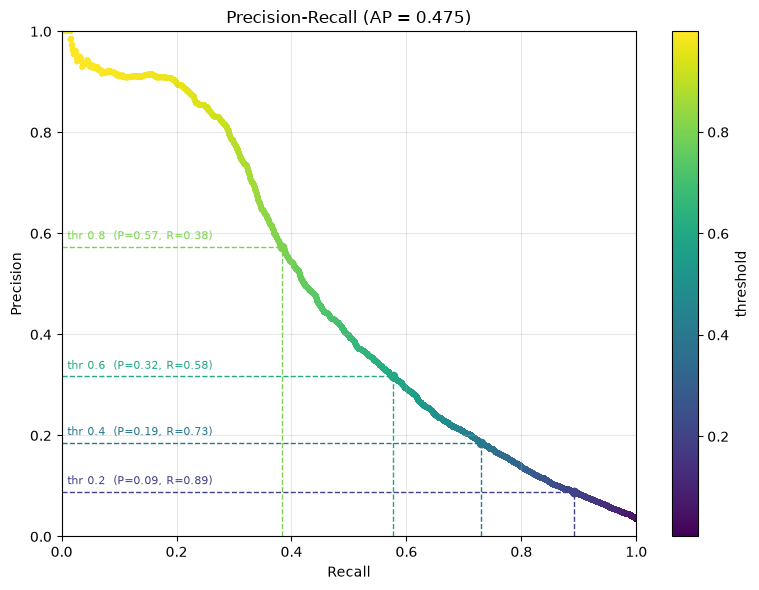

In [52]:
precision, recall, thresholds = precision_recall_curve(y_test, probs)
p, r = precision[:-1], recall[:-1]   # align with thresholds

fig, ax = plt.subplots(figsize=(8, 6))

sc = ax.scatter(r, p, c=thresholds, cmap='viridis', s=8)
plt.colorbar(sc, ax=ax, label='threshold')


targets = [0.2, 0.4, 0.6, 0.8]

for t in targets:
    i = np.searchsorted(thresholds, t)          # thresholds are ascending
    i = min(i, len(thresholds) - 1)
    r_t, p_t = r[i], p[i]
    
    color = sc.cmap(sc.norm(thresholds[i]))

    ax.hlines(p_t, 0, r_t, color=color, ls='--', lw=1)   # y-axis → curve
    ax.vlines(r_t, 0, p_t, color=color, ls='--', lw=1)   # x-axis → curve
    ax.plot(r_t, p_t, 'o', color=color, ms=6)
    ax.text(0.01, p_t + 0.015, f'thr {t}  (P={p_t:.2f}, R={r_t:.2f})',
            color=color, fontsize=8)


ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_title(f'Precision-Recall (AP = {average_precision_score(y_test, probs):.3f})')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

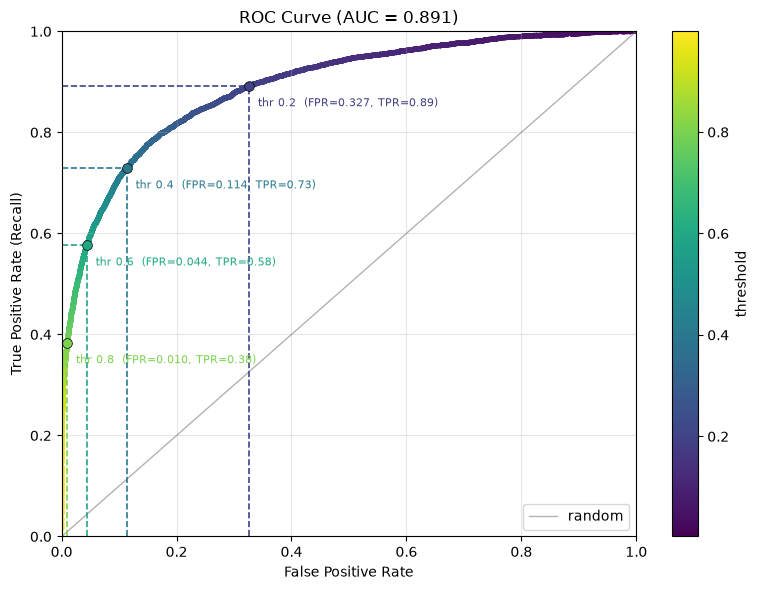

In [53]:
fpr, tpr, thresholds = roc_curve(y_test, probs)

# roc_curve prepends an infinite threshold for the (0,0) point — drop it
fpr, tpr, thresholds = fpr[1:], tpr[1:], thresholds[1:]

fig, ax = plt.subplots(figsize=(8, 6))

sc = ax.scatter(fpr, tpr, c=thresholds, cmap='viridis', s=8)
plt.colorbar(sc, ax=ax, label='threshold')

ax.plot([0, 1], [0, 1], ls='-', lw=1, color='grey', alpha=0.6, label='random')

targets = [0.2, 0.4, 0.6, 0.8]

for t in targets:
    i = np.argmin(np.abs(thresholds - t))       # thresholds are descending here
    f_t, tp_t = fpr[i], tpr[i]

    color = sc.cmap(sc.norm(thresholds[i]))

    ax.hlines(tp_t, 0, f_t, color=color, ls='--', lw=1.2)
    ax.vlines(f_t, 0, tp_t, color=color, ls='--', lw=1.2)
    ax.plot(f_t, tp_t, 'o', color=color, ms=7, mec='black', mew=0.5)
    ax.text(f_t + 0.015, tp_t - 0.04, f'thr {t}  (FPR={f_t:.3f}, TPR={tp_t:.2f})',
            color=color, fontsize=8)

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate (Recall)')
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_title(f'ROC Curve (AUC = {roc_auc_score(y_test, probs):.3f})')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### save training information

In [54]:
import joblib

precision, recall, thresholds = precision_recall_curve(y_test, probs)
print("PR-AUC:", average_precision_score(y_test, probs))

categorical_cols = list(X_train.select_dtypes(include='category').columns)

bundle = {
    'model': pipe3,
    'feature_order': list(X_train.columns),
    'categorical_cols': categorical_cols,
    'category_levels': {c: list(X_train[c].cat.categories) for c in categorical_cols},
    'pr_curve': {
        'thresholds': thresholds.tolist(),
        'precision': precision[:-1].tolist(),
        'recall': recall[:-1].tolist(),
    },
    'default_threshold': 0.5,
    'metrics': {
        'average_precision': float(average_precision_score(y_test, probs)),
        'roc_auc': float(roc_auc_score(y_test, probs)),
    },
    'trained_at': pd.Timestamp.now().isoformat(),
}

joblib.dump(bundle, '../app/models/fraud_model.joblib')

PR-AUC: 0.4749625387628848


['../app/models/fraud_model.joblib']

In [57]:
from pathlib import Path

out = Path.cwd().parents[0] / "app/dashboard/data"

# 10 rows, balanced 5/5, for the single-transaction scorer
scorer = pd.concat([
    X_test[y_test == 1].sample(5, random_state=42),
    X_test[y_test == 0].sample(5, random_state=42),
])
scorer = scorer.assign(isFraud=y_test.loc[scorer.index]).sample(frac=1, random_state=42)
scorer.to_csv(out / "sample_transactions.csv", index=False)

# 5000 rows at natural prevalence, for the evaluate page
evalset = X_test.sample(5000, random_state=42)
evalset = evalset.assign(isFraud=y_test.loc[evalset.index])
evalset.to_csv(out / "sample_eval.csv", index=False)

print(f"scorer: {len(scorer)} rows, {scorer['isFraud'].sum()} fraud")
print(f"evalset: {len(evalset)} rows, {evalset['isFraud'].sum()} fraud "
      f"({evalset['isFraud'].mean():.3%})")

/tmp/ipykernel_16197/3491694303.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  scorer = scorer.assign(isFraud=y_test.loc[scorer.index]).sample(frac=1, random_state=42)
/tmp/ipykernel_16197/3491694303.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  evalset = evalset.assign(isFraud=y_test.loc[evalset.index])


scorer: 10 rows, 5 fraud
evalset: 5000 rows, 165 fraud (3.300%)


In [58]:
import sklearn, xgboost; print(sklearn.__version__, xgboost.__version__)

1.8.0 3.2.0
